# 05 — Placebo tests and power

Pre-registered in `PREREGISTRATION.md`, section 6.

**Idea:** pretend that some pre-pandemic matches were played without fans, and estimate the "effect" exactly as in the main model.
Since fans were there, any "effect" is pure noise. If the real ghost estimate is no larger than typical placebo estimates, it could be noise too.

- **Placebo sample:** 2012/13–2018/19 (2010/11–2011/12 only warm up ELO).
- **Model:** `outcome ~ placebo + elo_diff + trend + C(Referee)` (no `var`: there was no VAR before 2019/20).
- **Season placebo:** each season 2014/15–2018/19 in turn is the fake ghost season (5 estimates).
- **Rolling placebo:** a block of 437 consecutive matches (the size of the real ghost group), starting at every 10th match.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
pd.set_option("display.width", 200)

matches = pd.read_csv(PROCESSED_DIR / "matches_elo.csv", parse_dates=["Date"])
main = pd.read_csv(PROCESSED_DIR / "results_main.csv").set_index("outcome")

placebo_sample = matches[matches["season_start"].between(2012, 2018)]
placebo_sample = placebo_sample.sort_values("Date", kind="stable").reset_index(drop=True)
print("Placebo sample:", placebo_sample.shape[0], "matches,", placebo_sample["Referee"].nunique(), "referees")

REAL = main["coef"].to_dict()
print("Real ghost estimates:", {k: round(v, 4) for k, v in REAL.items()})

Placebo sample: 2660 matches, 27 referees
Real ghost estimates: {'card_diff': -0.225, 'cpf_diff': -0.0082}


In [2]:
PLACEBO_RIGHT_SIDE = "placebo + elo_diff + trend + C(Referee)"
OUTCOMES = ["card_diff", "cpf_diff"]


def placebo_estimate(data, outcome):
    """Coefficient on the fake 'placebo' dummy. Only the point estimate is needed here."""
    data = data.dropna(subset=[outcome])
    return smf.ols(f"{outcome} ~ {PLACEBO_RIGHT_SIDE}", data=data).fit().params["placebo"]

## 1. Season placebo (5 estimates)

In [3]:
season_rows = []
for season in range(2014, 2019):
    data = placebo_sample.assign(placebo=(placebo_sample["season_start"] == season).astype(int))
    row = {"placebo_season": f"{season}/{str(season + 1)[2:]}"}
    for outcome in OUTCOMES:
        row[outcome] = placebo_estimate(data, outcome)
    season_rows.append(row)

season_placebo = pd.DataFrame(season_rows)
season_placebo.round(4)

,placebo_season,card_diff,cpf_diff
0,2014/15,0.0510,0.0058
1,2015/16,-0.0184,-0.0198
2,2016/17,-0.0382,-0.0078
3,2017/18,-0.0604,-0.0004
4,2018/19,0.1068,0.0218


## 2. Rolling placebo (about 220 estimates)

Blocks overlap, so neighbouring estimates are correlated. The share below is therefore a benchmark, not an exact p-value.

In [4]:
BLOCK_SIZE = 437      # number of real ghost matches
STEP = 10

rolling_rows = []
for start in range(0, len(placebo_sample) - BLOCK_SIZE + 1, STEP):
    flag = np.zeros(len(placebo_sample), dtype=int)
    flag[start:start + BLOCK_SIZE] = 1
    data = placebo_sample.assign(placebo=flag)

    row = {
        "start": start,
        "first_date": placebo_sample.loc[start, "Date"].date(),
        "last_date": placebo_sample.loc[start + BLOCK_SIZE - 1, "Date"].date(),
    }
    for outcome in OUTCOMES:
        row[outcome] = placebo_estimate(data, outcome)
    rolling_rows.append(row)

rolling_placebo = pd.DataFrame(rolling_rows)
print("Number of rolling placebo estimates:", len(rolling_placebo))
rolling_placebo[OUTCOMES].describe().round(4)

Number of rolling placebo estimates: 223


,card_diff,cpf_diff
count,223.0000,223.0000
mean,-0.0118,-0.0016
std,0.0701,0.0107
min,-0.1795,-0.0204
25%,-0.0524,-0.0108
50%,-0.0113,-0.0019
75%,0.0335,0.0070
max,0.1888,0.0216


## 3. How unusual is the real estimate?

In [5]:
summary_rows = []
for outcome in OUTCOMES:
    real = REAL[outcome]
    rolling = rolling_placebo[outcome]
    summary_rows.append({
        "outcome": outcome,
        "real_estimate": real,
        "rolling_placebo_sd": rolling.std(),
        "share_rolling_as_extreme": (rolling.abs() >= abs(real)).mean(),
        "rolling_min": rolling.min(),
        "rolling_max": rolling.max(),
        "share_season_as_extreme": (season_placebo[outcome].abs() >= abs(real)).mean(),
    })

placebo_summary = pd.DataFrame(summary_rows)
placebo_summary.round(4)

,outcome,real_estimate,rolling_placebo_sd,share_rolling_as_extreme,rolling_min,rolling_max,share_season_as_extreme
0,card_diff,-0.2250,0.0701,0.0000,-0.1795,0.1888,0.0
1,cpf_diff,-0.0082,0.0107,0.5874,-0.0204,0.0216,0.4


## 4. Minimum detectable effect

MDE = 2.8 × clustered SE of `ghost` from the main model (80% power, α = 0.05, two-sided).

In [6]:
for outcome in OUTCOMES:
    row = main.loc[outcome]
    print(f"{outcome}: estimate {row['coef']:+.3f}, MDE {row['mde']:.3f}. "
          f"With 80% power this design detects a true effect of at least {row['mde']:.3f} in absolute size.")

card_diff: estimate -0.225, MDE 0.209. With 80% power this design detects a true effect of at least 0.209 in absolute size.
cpf_diff: estimate -0.008, MDE 0.024. With 80% power this design detects a true effect of at least 0.024 in absolute size.


## 5. Figure 3: real estimate against the placebo distribution

One panel per outcome (different scales).

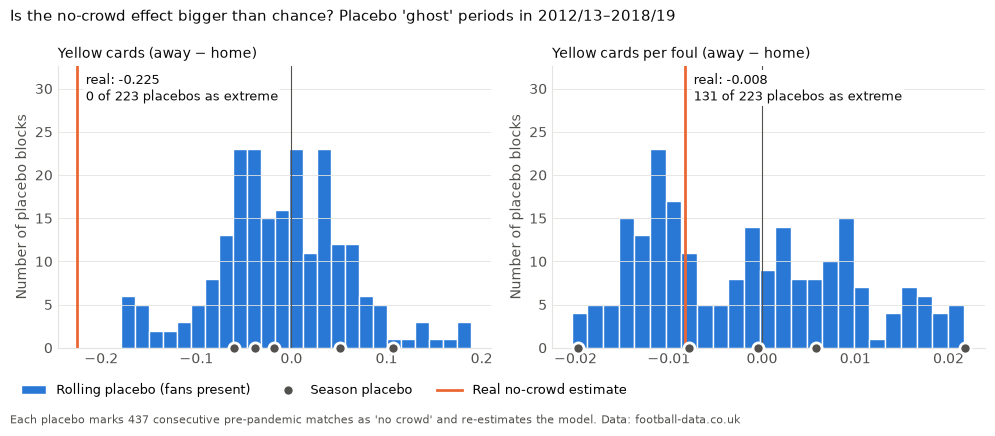

In [7]:
BLUE = "#2a78d6"
ORANGE = "#eb6834"
TEXT = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID = "#e4e3df"

plt.rcParams.update({
    "font.size": 10,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

TITLES = {"card_diff": "Yellow cards (away − home)", "cpf_diff": "Yellow cards per foul (away − home)"}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for ax, outcome in zip(axes, OUTCOMES):
    rolling = rolling_placebo[outcome]
    real = REAL[outcome]
    n_extreme = int((rolling.abs() >= abs(real)).sum())

    ax.hist(rolling, bins=25, color=BLUE, edgecolor="white", linewidth=1, label="Rolling placebo (fans present)")
    ax.plot(season_placebo[outcome], np.zeros(len(season_placebo)), "o", markersize=8, color=TEXT_SECONDARY,
            markeredgecolor="white", markeredgewidth=2, clip_on=False, zorder=3, label="Season placebo")
    ax.axvline(real, color=ORANGE, linewidth=2, label="Real no-crowd estimate")
    ax.annotate(f"real: {real:+.3f}\n{n_extreme} of {len(rolling)} placebos as extreme", (real, 1), xycoords=("data", "axes fraction"),
                xytext=(6, -4), textcoords="offset points", va="top", fontsize=9, color=TEXT,
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 1})
    ax.axvline(0, color=TEXT_SECONDARY, linewidth=0.8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.35)     # headroom for the label
    ax.set_title(TITLES[outcome], fontsize=10, color=TEXT, loc="left")
    ax.set_ylabel("Number of placebo blocks")
    ax.grid(axis="y", color=GRID, linewidth=0.6)
    ax.tick_params(length=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=9, ncol=3, loc="lower left", bbox_to_anchor=(0.01, -0.07))
fig.suptitle("Is the no-crowd effect bigger than chance? Placebo 'ghost' periods in 2012/13–2018/19",
             fontsize=11, color=TEXT, x=0.01, ha="left")
fig.text(0.01, -0.11, "Each placebo marks 437 consecutive pre-pandemic matches as 'no crowd' and re-estimates the model. "
         "Data: football-data.co.uk", fontsize=8, color=TEXT_SECONDARY)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_placebo.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 6. Save

In [8]:
season_placebo.to_csv(PROCESSED_DIR / "placebo_season.csv", index=False)
rolling_placebo.to_csv(PROCESSED_DIR / "placebo_rolling.csv", index=False)
placebo_summary.to_csv(PROCESSED_DIR / "placebo_summary.csv", index=False)
print("Saved placebo results to data/processed/")

Saved placebo results to data/processed/
